# Steam Tables — Milestone 13

Steam tables are the single most-used thermodynamic reference in chemical-engineering practice: sizing reboilers and condensers, balancing steam headers, recovering flash steam, and rating turbines and valves. Every printed steam table in a modern handbook is *computed from* one open standard — the **IAPWS Industrial Formulation 1997 (IF97)** — so `vle-steam` implements that standard directly rather than interpolating tabulated numbers.

This is, in effect, **VLE for water only**: a companion to the multicomponent `vle-thermo` engine, surfaced in Python as `vle.steam`. In this notebook we reproduce a printed saturation-table page, then work four scenarios an engineer meets weekly.

## Setup (optional)

The cell below is **commented out** — the notebook runs top-to-bottom against whatever `vle-thermo` is already in your kernel. Uncomment it to pull the newest released wheel from PyPI.

In [1]:
# Optional: pull the latest vle-thermo from PyPI.
# Uncomment if you want the newest released version instead of
# whatever is currently in your kernel.
# %pip install --upgrade vle-thermo

## Context from the research paper

The thesis this project modernizes is about the vapor–liquid equilibrium of *mixtures* via cubic equations of state; steam tables are the **pure-water reference standard** for exactly the energy properties it derives. From [Chapter II §2.1.3 — Energy Properties based on CEOS](../docs/en/research-paper/chapter-2-vle-theory.md#213-energy-properties-based-on-ceos):

> The calculation of energy properties (enthalpy and entropy) is essential for the energy balances of separation processes; these are obtained from the equation of state through the departure functions referenced to an ideal-gas state.

For water specifically, IF97 replaces a cubic EOS with a purpose-built, reference-quality formulation. The same *(P, h)* and *(P, s)* flashes that Chapter II §2.3.2 describes for mixtures appear here as the throttling-valve and turbine calculations below — only now the numbers match a handbook to nine significant figures.

## What Milestone 13 built

A new dependency-free workspace crate **`vle-steam`** implementing all five IF97 regions plus the saturation line and backward equations, surfaced as **`vle.steam`**:

| Region | Domain | Equation |
|---|---|---|
| 1 | compressed liquid, 273–623 K | Gibbs $g(p,T)$ |
| 2 | superheated vapor, ≤ 1073 K | Gibbs $g(p,T)$ |
| 3 | near-critical | Helmholtz $f(\rho,T)$ (density iteration) |
| 4 | **saturation line**, 273–647 K | closed-form both ways |
| 5 | high-T steam, ≤ 2273 K | Gibbs $g(p,T)$ |

The Python surface:

- **`steam.Water(...)`** — a state from any of the pairs `(T,P)`, `(T,x)`, `(P,x)`, `(P,h)`, `(P,s)`; returns `T, P, region, phase, x, ρ, v, u, h, s, cp, cv, w`.
- **`steam.saturation(T=…)` / `(P=…)`** — the printed saturation-table row (`v_f, v_g, h_f, h_g, h_fg, s_f, s_g, s_fg, u_f, u_g`).
- **`steam.psat` / `tsat` / `latent_heat` / `psat_derivative`** — scalar helpers.
- **`steam.properties` / `ph_flash` / `sat_table`** — batch numpy kernels (the GIL-released, rayon-parallel "numpy for thermo" path).

All properties are **mass-basis** (kJ/kg, kJ/(kg·K), m³/kg). Inputs accept plain floats (`T` in K, `P` in kPa absolute), `pint` quantities, or unit strings like `"180 degC"` and `"10 barg"` — gauge pressure is resolved through the same registry the engine uses.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from vle import steam

# A single (T, P) state — compressed liquid water at 300 K, 3 MPa.
# This is R7-97(2012) Table 5 verification point 1.
st = steam.Water(T=300.0, P=3000.0)  # K, kPa absolute
print(st)
print(f"region {st.region}  phase {st.phase}")
print(f"h = {st.h:.6f} kJ/kg   (IAPWS: 115.331273)")
assert abs(st.h - 115.331273) < 1e-5

SteamState(T=300.0000 K, P=3000.0000 kPa, region=1, phase=liquid, h=115.331273 kJ/kg)
region 1  phase liquid
h = 115.331273 kJ/kg   (IAPWS: 115.331273)


## A printed saturation-table page

The classic steam-table page: pick a column of temperatures and read off saturation pressure, the saturated-liquid and -vapor volumes, enthalpies, and entropies. `steam.sat_table` returns these as numpy columns in one GIL-released call.

In [3]:
T_C = np.array([50, 100, 150, 200, 250, 300, 350], dtype=float)  # °C
tab = steam.sat_table(T_C + 273.15)

print(f"{'T[°C]':>6} {'Psat[kPa]':>11} {'v_f[m³/kg]':>12} "
      f"{'v_g[m³/kg]':>12} {'h_f[kJ/kg]':>11} {'h_g[kJ/kg]':>11} "
      f"{'h_fg[kJ/kg]':>12}")
for i, t in enumerate(T_C):
    print(f"{t:6.0f} {tab['p'][i]:11.3f} {tab['v_f'][i]:12.6f} "
          f"{tab['v_g'][i]:12.5f} {tab['h_f'][i]:11.2f} "
          f"{tab['h_g'][i]:11.2f} {tab['h_fg'][i]:12.2f}")

# Spot-check the 100 °C row against the handbook (1 atm boiling).
assert abs(tab['p'][1] - 101.42) < 0.1        # Psat(100°C) ≈ 101.4 kPa
assert abs(tab['h_fg'][1] - 2256.5) < 1.0     # latent heat ≈ 2257 kJ/kg

 T[°C]   Psat[kPa]   v_f[m³/kg]   v_g[m³/kg]  h_f[kJ/kg]  h_g[kJ/kg]  h_fg[kJ/kg]
    50      12.351     0.001012     12.02786      209.34     2591.31      2381.97
   100     101.418     0.001043      1.67186      419.10     2675.57      2256.47
   150     476.101     0.001091      0.39250      632.25     2745.92      2113.67
   200    1554.672     0.001157      0.12722      852.39     2792.06      1939.67
   250    3975.939     0.001252      0.05009     1085.69     2801.01      1715.33
   300    8587.708     0.001404      0.02166     1344.77     2749.57      1404.80
   350   16529.164     0.001740      0.00880     1670.86     2563.59       892.73


### The saturation dome

Plotting the saturated-liquid and -vapor entropies against temperature traces the two-phase **dome** on a *T–s* diagram — the map every turbine and refrigeration cycle is drawn on. The apex is the critical point (647.096 K, 22.064 MPa).

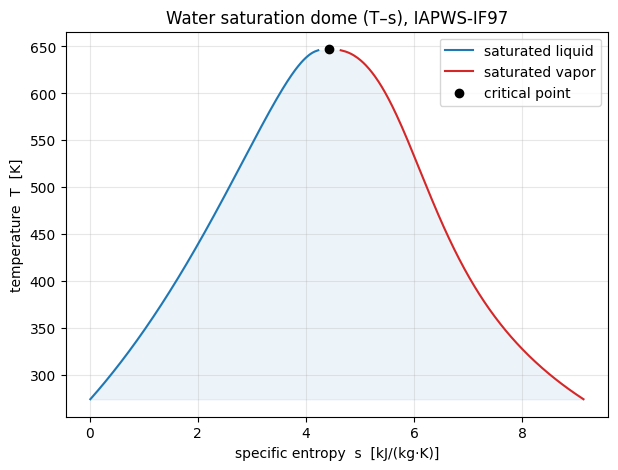

In [4]:
Tdome = np.linspace(274.0, 646.0, 280)
dome = steam.sat_table(Tdome)

# Critical point: entropy → the common value of s_f, s_g as T → Tc.
s_near_crit = steam.saturation(T=646.5)
s_crit = 0.5 * (s_near_crit.s_f + s_near_crit.s_g)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(dome['s_f'], Tdome, color='#1f77b4', label='saturated liquid')
ax.plot(dome['s_g'], Tdome, color='#d62728', label='saturated vapor')
ax.fill_betweenx(Tdome, dome['s_f'], dome['s_g'],
                 color='#1f77b4', alpha=0.08)
ax.scatter([s_crit], [647.096],
           color='k', zorder=5, label='critical point')
ax.set_xlabel('specific entropy  s  [kJ/(kg·K)]')
ax.set_ylabel('temperature  T  [K]')
ax.set_title('Water saturation dome (T–s), IAPWS-IF97')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## Worked example — an isentropic steam turbine

Steam enters a turbine at **40 bar, 400 °C** and expands to the condenser at **0.1 bar**. The turbine is 80 % isentropically efficient. Find the **outlet quality** and the **specific work**.

The recipe is the textbook one, and it uses three `Water` modes:

1. **Inlet state** from `(T, P)` → gives $h_1$ and $s_1$.
2. **Ideal (isentropic) outlet** from `(P_\text{out}, s_1)` → the reversible enthalpy $h_{2s}$.
3. **Actual outlet** from the efficiency: $h_2 = h_1 - \eta\,(h_1 - h_{2s})$, then `(P_\text{out}, h_2)` for the real quality.

> Note the gauge-vs-absolute care: `"40 bar"` here is absolute. Use `"40 barg"` for gauge — the registry adds the atmospheric offset automatically.

In [5]:
eta = 0.80
inlet = steam.Water(T='400 degC', P='40 bar')      # absolute
print('inlet :', inlet)

# Ideal expansion is isentropic: same entropy, condenser pressure.
ideal = steam.Water(P='0.1 bar', s=inlet.s)
h2s = ideal.h

# Real machine: 80% of the ideal enthalpy drop is realized.
h2 = inlet.h - eta * (inlet.h - h2s)
outlet = steam.Water(P='0.1 bar', h=h2)

work = inlet.h - outlet.h            # kJ/kg
print('ideal outlet :', ideal, f'  x_ideal={ideal.x:.4f}')
print('real  outlet :', outlet, f'  x_real ={outlet.x:.4f}')
print(f'\nspecific work  w = {work:.1f} kJ/kg')
print(f'exhaust is {outlet.phase} at x = {outlet.x:.3f} '
      f'(T = {outlet.t-273.15:.2f} °C)')

# Sanity: real exhaust is wetter than ideal, both inside the dome.
assert 0.0 < ideal.x < outlet.x < 1.0
assert work > 0

inlet : SteamState(T=673.1500 K, P=4000.0000 kPa, region=2, phase=vapor, h=3214.373509 kJ/kg)
ideal outlet : SteamState(T=318.9575 K, P=10.0000 kPa, region=4, phase=two-phase, h=2144.459331 kJ/kg)   x_ideal=0.8163
real  outlet : SteamState(T=318.9575 K, P=10.0000 kPa, region=4, phase=two-phase, h=2358.442167 kJ/kg)   x_real =0.9058

specific work  w = 855.9 kJ/kg
exhaust is two-phase at x = 0.906 (T = 45.81 °C)


The 80 %-efficient machine leaves the steam **wetter** (lower quality) than the reversible one — irreversibility shows up as extra entropy, pushing the exhaust point rightward under the dome. Excessive wetness erodes turbine blades, which is why the exhaust quality is a design constraint. Let's draw both expansion paths on the *T–s* dome.

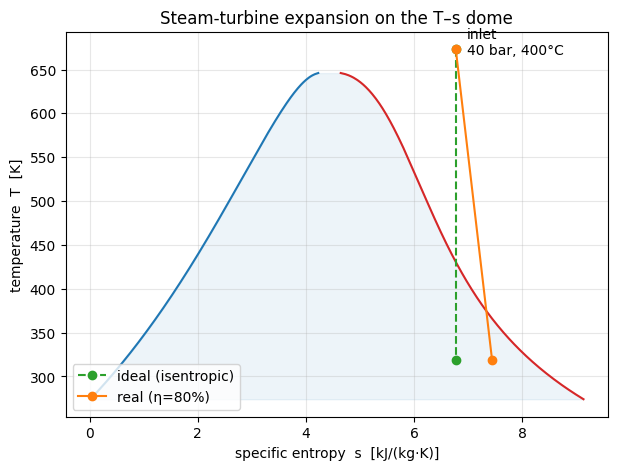

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(dome['s_f'], Tdome, color='#1f77b4')
ax.plot(dome['s_g'], Tdome, color='#d62728')
ax.fill_betweenx(Tdome, dome['s_f'], dome['s_g'], color='#1f77b4', alpha=0.08)

# Expansion paths (vertical = isentropic ideal; slanted = real).
ax.plot([inlet.s, ideal.s], [inlet.t, ideal.t], 'o--', color='#2ca02c',
        label='ideal (isentropic)')
ax.plot([inlet.s, outlet.s], [inlet.t, outlet.t], 'o-', color='#ff7f0e',
        label=f'real (η={eta:.0%})')
ax.annotate('inlet\n40 bar, 400°C', (inlet.s, inlet.t),
            textcoords='offset points', xytext=(8, -4))
ax.set_xlabel('specific entropy  s  [kJ/(kg·K)]')
ax.set_ylabel('temperature  T  [K]')
ax.set_title('Steam-turbine expansion on the T–s dome')
ax.legend(loc='lower left')
ax.grid(alpha=0.3)
plt.show()

## Exercises

Two scenarios from daily practice. Try each in the template cell, then expand the solution to check.

### Exercise 1 — Flash-steam recovery

Saturated condensate leaves a steam trap at **10 barg** and is throttled to a flash vessel at **1 barg**. Throttling is isenthalpic (a valve does no work and — ideally — loses no heat). **What mass fraction of the condensate flashes to steam?**

Hint: the condensate starts as saturated liquid ($x=0$) at 10 barg; its enthalpy is conserved through the valve; the downstream state is a `(P, h)` flash at 1 barg.

In [7]:
# TODO:
# 1. inlet = saturated liquid at 10 barg   -> steam.Water(P='10 barg', x=0.0)
# 2. flash to 1 barg at constant enthalpy  -> steam.Water(P='1 barg', h=inlet.h)
# 3. the flashed fraction is the downstream quality x
flashed_fraction = ...
# print(f'{flashed_fraction:.1%} of the condensate flashes to steam')

<details>
<summary>Solution</summary>

```python
inlet = steam.Water(P='10 barg', x=0.0)      # saturated condensate
flash = steam.Water(P='1 barg', h=inlet.h)   # isenthalpic throttle
flashed_fraction = flash.x
print(f'{flashed_fraction:.1%} of the condensate flashes to steam')
print(f'downstream: {flash.phase} at {flash.t-273.15:.1f} °C')
```

About **13–14 %** of the condensate flashes — that flash steam is worth recovering to a low-pressure header instead of venting it. The driving force is the drop in saturation temperature: the liquid arrives hotter than its new boiling point, and the excess sensible heat boils part of it off.
</details>

In [8]:
# Reference solution (executed so the notebook self-checks).
inlet = steam.Water(P='10 barg', x=0.0)
flash = steam.Water(P='1 barg', h=inlet.h)
print(f'flashed fraction = {flash.x:.1%}')
assert 0.10 < flash.x < 0.16
assert flash.phase == 'two-phase'

flashed fraction = 12.5%


### Exercise 2 — Reboiler steam demand

A distillation reboiler needs **Q = 500 kW** of heat, supplied by condensing **4 barg** saturated steam (it enters as saturated vapor and leaves as saturated liquid, giving up its latent heat). **What steam flow rate, in kg/h, does the reboiler consume?**

Hint: each kg of condensing steam releases $h_{fg}$ at 4 barg; the mass flow is $\dot m = Q / h_{fg}$.

In [9]:
Q_kW = 500.0
# TODO:
# 1. latent heat at 4 barg (kJ/kg) -> steam.latent_heat(...) or saturation(...).h_fg
# 2. mass flow (kg/s) = Q / h_fg,  then × 3600 for kg/h
m_dot_kg_per_h = ...
# print(f'{m_dot_kg_per_h:.0f} kg/h of 4 barg steam')

<details>
<summary>Solution</summary>

```python
sat = steam.saturation(P='4 barg')     # 4 barg ≈ 506 kPa absolute
h_fg = sat.h_fg                        # kJ/kg
m_dot = Q_kW / h_fg                    # kJ/s ÷ kJ/kg = kg/s
m_dot_kg_per_h = m_dot * 3600.0
print(f'Tsat = {sat.t-273.15:.1f} °C, h_fg = {h_fg:.0f} kJ/kg')
print(f'steam demand = {m_dot_kg_per_h:.0f} kg/h')
```

At 4 barg the latent heat is ≈ 2100 kJ/kg, so 500 kW needs roughly **850 kg/h** of steam. Higher-pressure steam carries *less* latent heat per kg (the dome narrows), so a hotter reboiler that runs on high-pressure steam actually needs a slightly larger mass flow for the same duty — a small but real design consideration.
</details>

In [10]:
# Reference solution (executed so the notebook self-checks).
sat = steam.saturation(P='4 barg')
m_dot_kg_per_h = Q_kW / sat.h_fg * 3600.0
print(f'steam demand = {m_dot_kg_per_h:.0f} kg/h  (h_fg={sat.h_fg:.0f} kJ/kg)')
assert 800 < m_dot_kg_per_h < 900

steam demand = 854 kg/h  (h_fg=2108 kJ/kg)


## References

- IAPWS. *Revised Release on the IAPWS Industrial Formulation 1997 for the Thermodynamic Properties of Water and Steam*; IAPWS R7-97(2012). The equations and the verification tables `vle-steam` is tested against.
- Wagner, W.; Kretzschmar, H.-J. *International Steam Tables*, 3rd ed.; Springer, 2019. The textbook form of IF97.
- Research paper: [Chapter II §2.1.3 — Energy Properties](../docs/en/research-paper/chapter-2-vle-theory.md#213-energy-properties-based-on-ceos) and [§2.3.2 — Flash Calculations](../docs/en/research-paper/chapter-2-vle-theory.md#232-flash-calculations) (the mixture analog of the `(P,h)`/`(P,s)` flashes used here).
- Design record: `STEAM_TABLES_PLAN.md` (Milestone 13); `MODERNIZATION_PLAN.md` Phase 20.

**Why this milestone exists:** water is the working fluid of most of the process industry, and its properties are a solved problem with an open reference standard. Shipping IF97 directly — dependency-free and tested to nine significant figures — gives every downstream energy balance a trustworthy water model, and gives the planned iOS build its first natural app: a steam-table calculator in your pocket.